In [1]:
from DataPreparation import *
from tqdm import tqdm

from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split, ParameterGrid

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import math

#### Uncertainty plots

In [2]:
def plot_comparison(df_orig, img_orig, df_corr, img_corr, plot_fn, show_global_bar=False, **kwargs):
    """
    Create a side-by-side comparison plot using the provided plotting function.

    Parameters:
      df_orig (pd.DataFrame): DataFrame for the original image.
      img_orig (np.ndarray): Original image.
      df_corr (pd.DataFrame): DataFrame for the corrupted image.
      img_corr (np.ndarray): Corrupted image.
      plot_fn (callable): Plotting function to use (e.g., plot_mean_with_color_gradient or plot_mean_with_uncertainty).
    
    Returns:
      tuple: (fig, (ax1, ax2))
    """
    # Create figure and two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Plot for original image
    fig, ax1, scatter1 = plot_fn(df_orig, img=img_orig, fig=fig, ax=ax1, **kwargs)
    ax1.axis('off')

    # Plot for corrupted image
    fig, ax2, scatter2 = plot_fn(df_corr, img=img_corr, fig=fig, ax=ax2, **kwargs)
    ax2.axis('off')

    # If 'show_bar' is specified and True, add a shared colorbar
    if show_global_bar:
        cbar = fig.colorbar(scatter1, ax=[ax1, ax2], orientation='vertical', fraction=0.05)
        plt.tight_layout()
        plt.subplots_adjust(right=0.85)
        cbar.ax.set_position([0.87, 0.15, 0.03, 0.7])

    return fig, (ax1, ax2)

In [4]:
def plot_global_uncertainty(sigma_dict, ylabel='', title='', ax=None):
    """Plots global uncertainty using a boxplot and returns fig, ax."""
    data = []
    labels = []

    for key, value in sigma_dict.items():
        data.append(np.array(value).flatten())
        labels.append(key)

    # If ax is provided, plot on the existing axes
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure  # If ax is passed, we use the provided figure

    # Pass labels to seaborn so tick indexing aligns
    sns.boxplot(data=data, ax=ax)

    total_labels = len(labels)

    # Generate tick indices and labels every 20 steps
    tick_indices = list(range(0, total_labels, 2))
    tick_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(tick_indices)
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=13)

    ax.set_ylabel(ylabel, fontsize=19)
    ax.set_xlabel('Gaussian Noise Level (σ)', fontsize=19, labelpad=15)
    ax.set_title(title, fontsize=22)
    ax.tick_params(axis='x', labelsize=15)  
    ax.tick_params(axis='y', labelsize=15)

    return fig, ax

output_dir = 'Outputs/Predictions/Skip/Corrupted/'
output_dir = 'Outputs/Predictions/NoSkip/Corrupted/'

noise_skip = process_and_store_sigma(os.path.join(output_dir, 'Noise'))
noise_noskip = process_and_store_sigma(os.path.join(output_dir, 'Noise'))

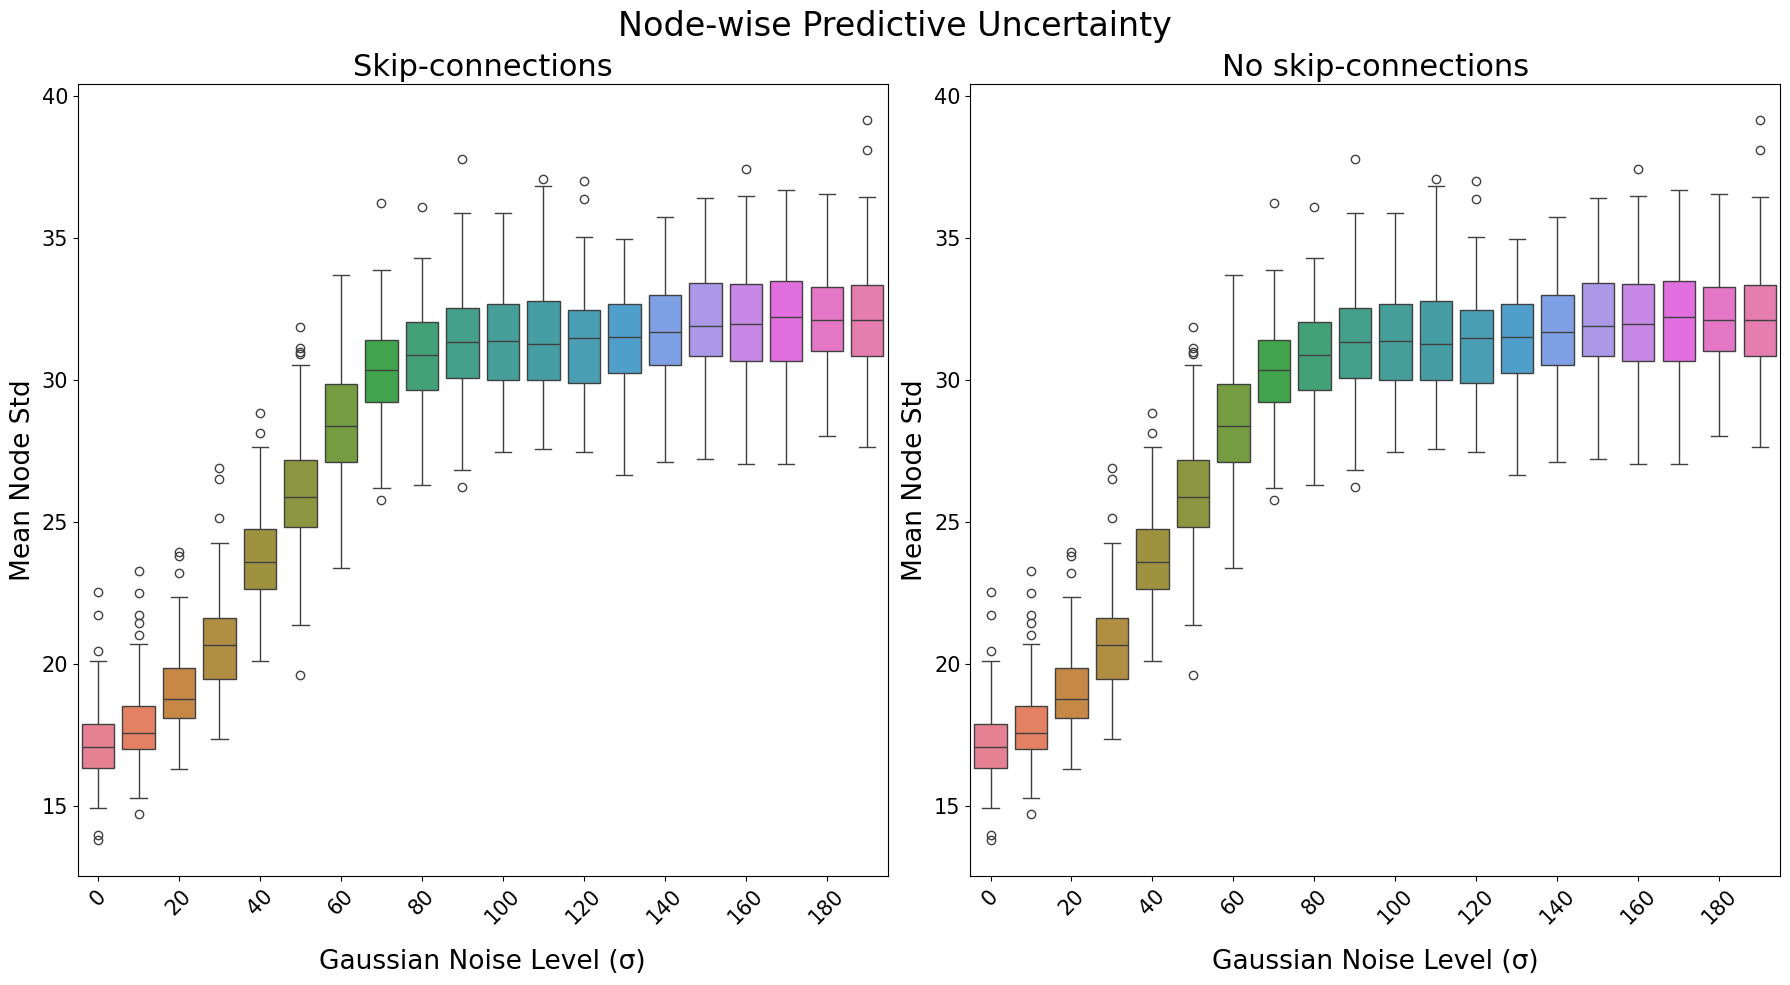

In [5]:
sigmas_global_skip = defaultdict(list)
sigmas_global_noskip = defaultdict(list)

for val in noise_skip.values():
    for sigma, corr_level in zip(val['sigmas'], val['corr_levels']):
        sigmas_global_skip[corr_level].append(sigma.mean())

for val in noise_noskip.values():
    for sigma, corr_level in zip(val['sigmas'], val['corr_levels']):
        sigmas_global_noskip[corr_level].append(sigma.mean())

# Example plotting
fig, axs = plt.subplots(1, 2, figsize=(18, 10))

# Plot the data
plot_global_uncertainty(sigmas_global_skip, ylabel='Mean Node Std', title='Skip-connections', ax=axs[0])
plot_global_uncertainty(sigmas_global_noskip, ylabel='Mean Node Std',  title='No skip-connections', ax=axs[1])

# Add overall title
fig.suptitle('Node-wise Predictive Uncertainty', fontsize=24)

# Adjust layout
fig.subplots_adjust(top=0.9, wspace=0.1)
plt.tight_layout()

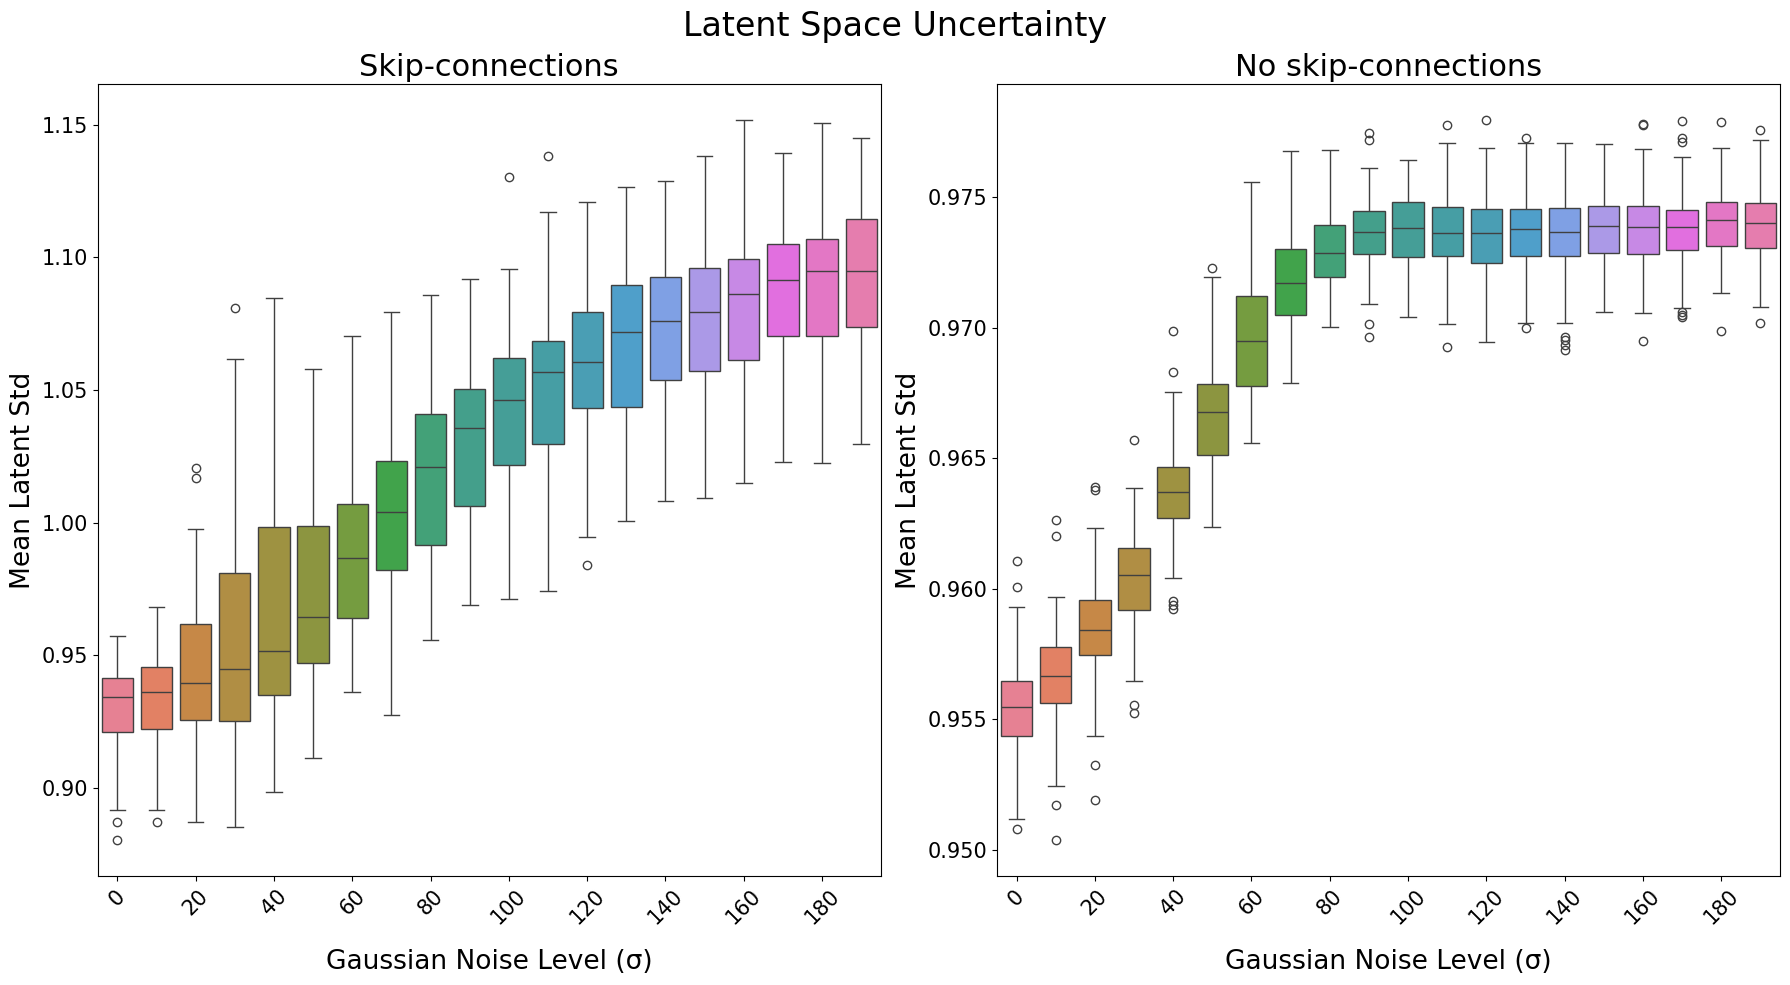

In [6]:
sigmas_global_skip = defaultdict(list)
file_path_skip = 'Outputs/Predictions/Skip/Corrupted/Noise/'
latent_sigmas_skip = read_sigma_files(file_path_skip)

sigmas_global_noskip = defaultdict(list)
file_path_noskip = 'Outputs/Predictions/NoSkip/Corrupted/Noise/'
latent_sigmas_noskip = read_sigma_files(file_path_noskip)

for val in latent_sigmas_skip.values():
    for sigma, corr_level in zip(val['sigmas'], val['corr_levels']):
        sigmas_global_skip[corr_level].append(sigma.mean())

for val in latent_sigmas_noskip.values():
    for sigma, corr_level in zip(val['sigmas'], val['corr_levels']):
        sigmas_global_noskip[corr_level].append(sigma.mean())

fig, axs = plt.subplots(1, 2, figsize=(18, 10))

plot_global_uncertainty(sigmas_global_skip, ylabel='Mean Latent Std', title='Skip-connections', ax=axs[0])
plot_global_uncertainty(sigmas_global_noskip, ylabel='Mean Latent Std', title='No skip-connections', ax=axs[1])

fig.suptitle('Latent Space Uncertainty', fontsize=24)
fig.subplots_adjust(top=0.9, wspace=0.1)
plt.tight_layout()

/tmp/ipykernel_2403344/1602606754.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


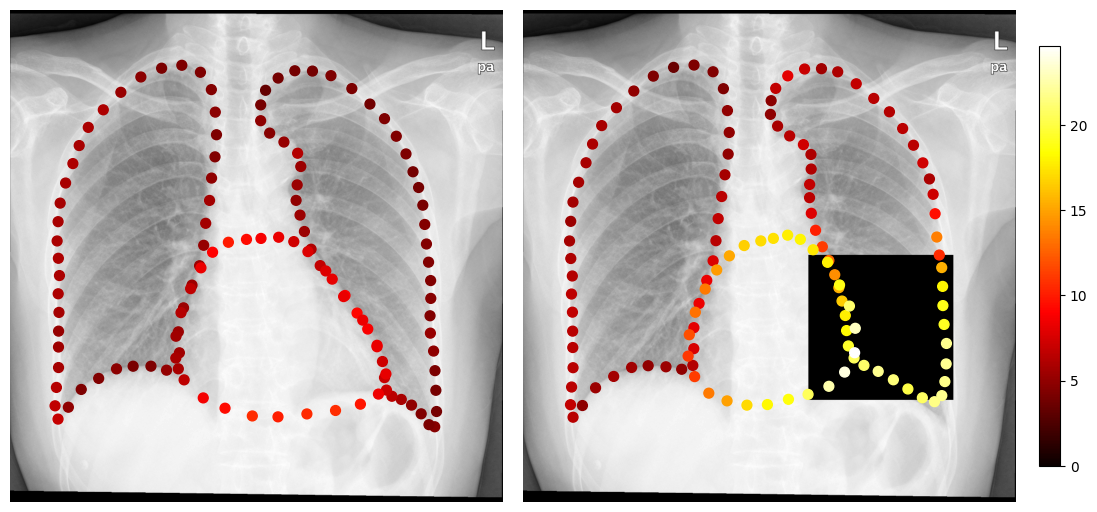

In [3]:
img_dir_corr = 'Outputs/Images/Corrupted/Occlusion/1'
img_dir = 'Outputs/Images/Clean'

img_name = 'CHNCXR_0096_0.png'

df_corr, img_corr = load_image_and_samples(img_name, img_dir_corr)
df_orig, img_orig = load_image_and_samples(img_name, img_dir)

vmax = compute_global_vmax(df_orig, df_corr)

fig, axes = plot_comparison(
    df_orig, img_orig, df_corr, img_corr,
    plot_fn=plot_mean_with_color_gradient,
    show_global_bar=True,
    vmax=vmax,
    show_bar=False
)

#### OOD detection 

In [2]:
import pickle

with open("sigmas_skip.pkl", "rb") as f:
    sigmas_skip = pickle.load(f)

with open("sigmas_noskip.pkl", "rb") as f:
    sigmas_noskip = pickle.load(f)

In [ ]:
sigmas_id_skip, sigmas_ood_skip, sigmas_id_noskip, sigmas_ood_noskip = {}, {}, {}, {}
latents_id_skip, latents_ood_skip, latents_id_noskip, latents_ood_noskip = {}, {}, {}, {}

for dataset in datasets:
    sigmas_id_skip[dataset] = sigmas_skip[dataset]['id']
    sigmas_ood_skip[dataset] = sigmas_skip[dataset]['ood']
    sigmas_id_noskip[dataset] = sigmas_noskip[dataset]['id']
    sigmas_ood_noskip[dataset] = sigmas_noskip[dataset]['ood']

In [28]:
def plot_kde_comparison_grid(
    id_skip, ood_skip, id_noskip, ood_noskip, datasets, 
    clip_skip=(0, 100), clip_noskip=(0, 100),
    n_cols=5, height_per_row=6):
    
    n_rows = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, height_per_row * n_rows))
    axes = axes.reshape(n_rows, n_cols)

    for i, dataset in enumerate(datasets):
        col = i % n_cols

        # Flexible clip handling
        clip_skip_val = clip_skip[dataset] if isinstance(clip_skip, dict) else clip_skip
        clip_noskip_val = clip_noskip[dataset] if isinstance(clip_noskip, dict) else clip_noskip

        # --- Skip row ---
        ax_skip = axes[0, col]
        sns.kdeplot(ood_skip[dataset], fill=True, color="red", label="OOD", ax=ax_skip, alpha=0.5, clip=clip_skip_val)
        sns.kdeplot(id_skip[dataset], fill=True, color="blue", label="ID", ax=ax_skip, alpha=0.5, clip=clip_skip_val)
        ax_skip.set_xlim(left=0)
        if col == 0:
            ax_skip.set_ylabel("Density", fontsize=17)
        else:
            ax_skip.set_ylabel("")  # only first column has ylabel
        ax_skip.set_xlabel("")  # only bottom row has xlabel
        ax_skip.set_title(dataset, fontsize=19)
        ax_skip.legend(fontsize=13)
        ax_skip.tick_params(axis='both', labelsize=14)

        # --- No-skip row ---
        ax_noskip = axes[1, col]
        sns.kdeplot(ood_noskip[dataset], fill=True, color="red", label="OOD", ax=ax_noskip, alpha=0.5, clip=clip_noskip_val)
        sns.kdeplot(id_noskip[dataset], fill=True, color="blue", label="ID", ax=ax_noskip, alpha=0.5, clip=clip_noskip_val)
        ax_noskip.set_xlim(left=0)
        if col == 0:
            ax_noskip.set_ylabel("Density", fontsize=17)
        else:
            ax_noskip.set_ylabel("")  # only first column has ylabel
        ax_noskip.set_xlabel("Sigma", fontsize=17)
        ax_noskip.legend(fontsize=13)
        ax_noskip.tick_params(axis='both', labelsize=14)

    # Match y-limits per row
    y_skip_max = max(ax.get_ylim()[1] for ax in axes[0, :len(datasets)])
    y_noskip_max = max(ax.get_ylim()[1] for ax in axes[1, :len(datasets)])
    for ax in axes[0, :len(datasets)]:
        ax.set_ylim(0, y_skip_max)
    for ax in axes[1, :len(datasets)]:
        ax.set_ylim(0, y_noskip_max)

    # Row labels
    fig.text(0.01, 0.74, 'Skip-connections', va='center', ha='left', rotation='vertical', fontsize=19, fontweight='bold')
    fig.text(0.01, 0.28, 'No skip-connections', va='center', ha='left', rotation='vertical', fontsize=19, fontweight='bold')

    plt.tight_layout(rect=[0.025, 0, 1, 0.99], pad=2.0)
    return fig, axes


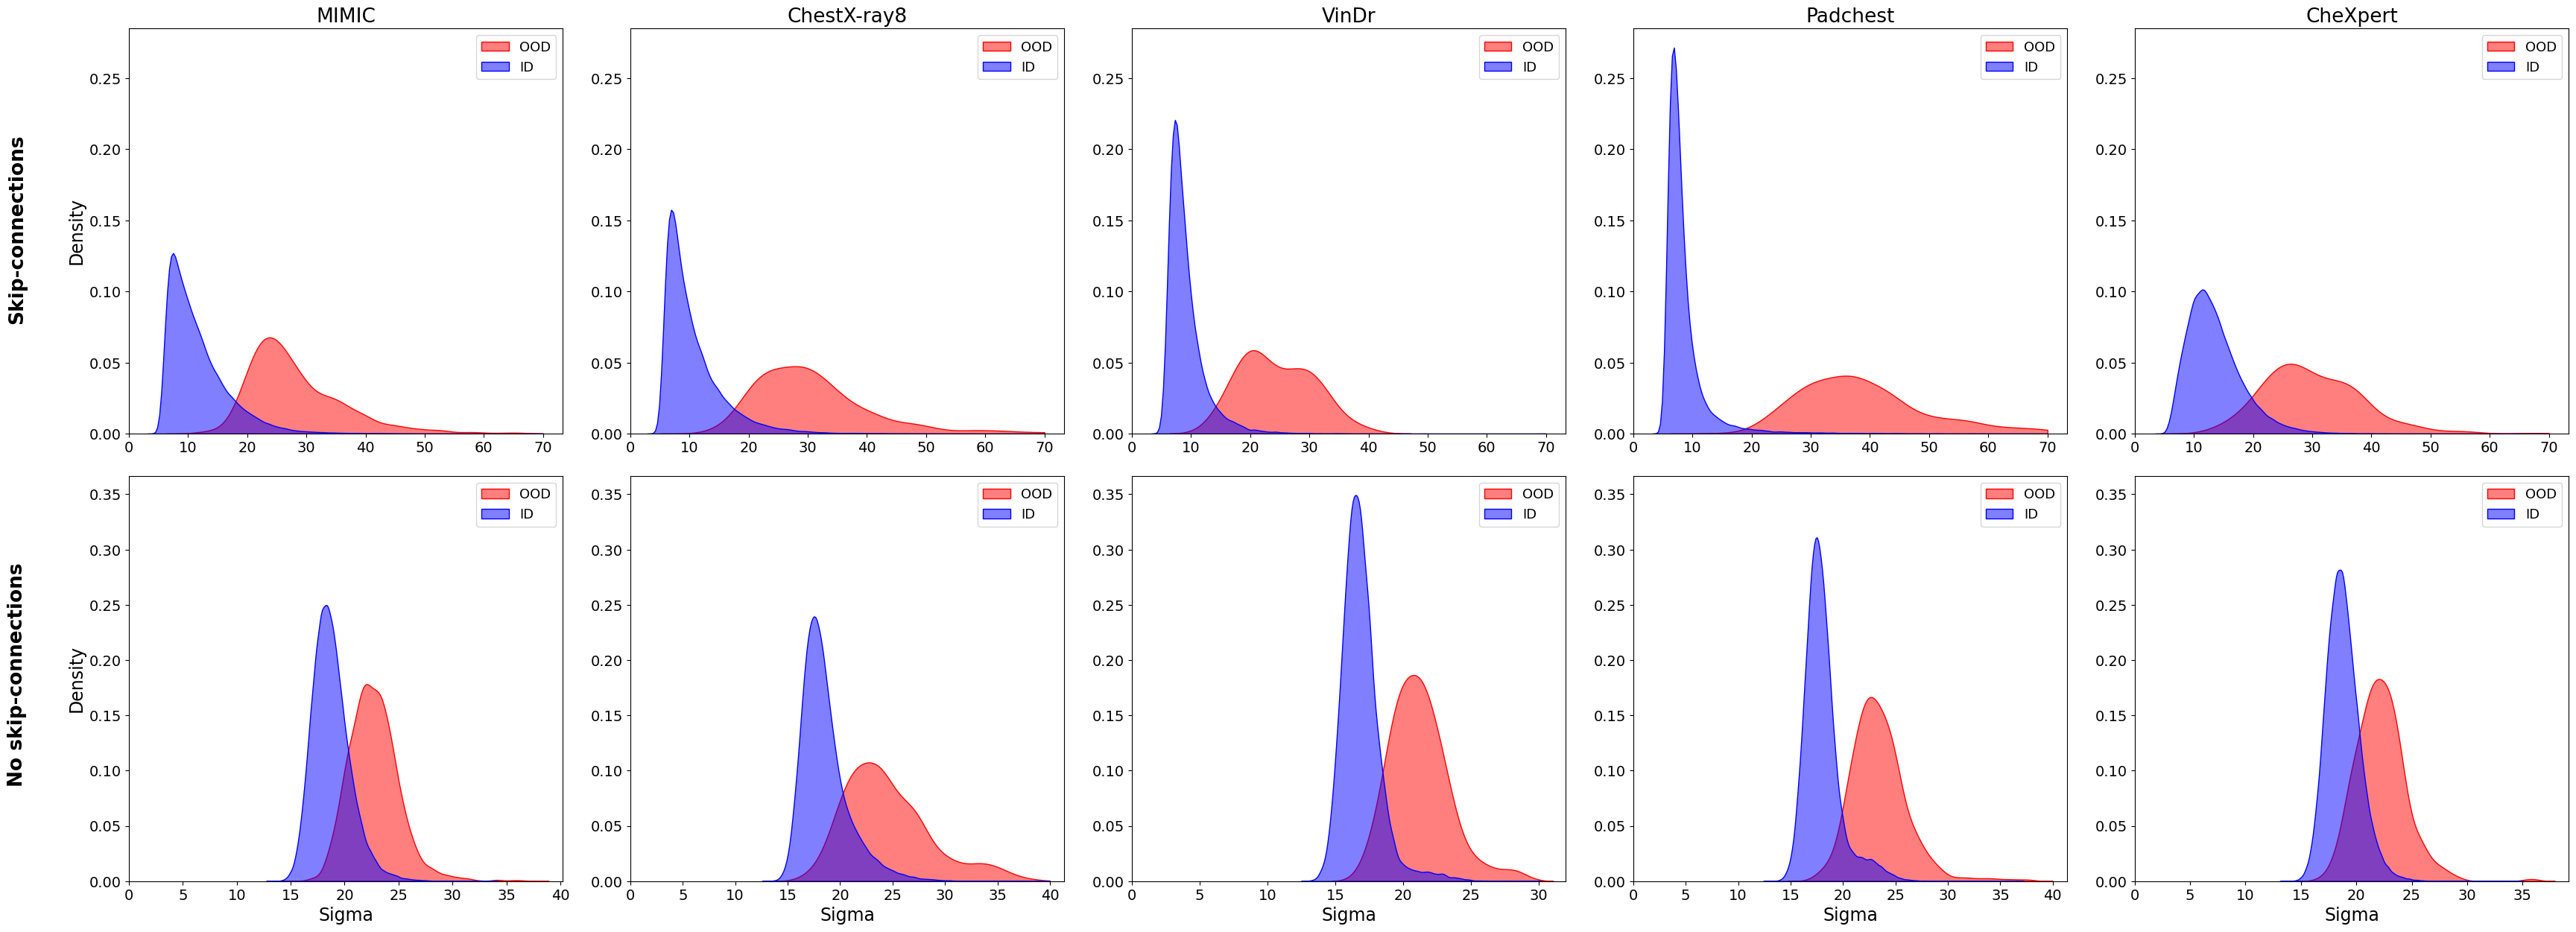

In [30]:
fig, axes = plot_kde_comparison_grid(
    id_skip=sigmas_id_skip,
    ood_skip=sigmas_ood_skip,
    id_noskip=sigmas_id_noskip,
    ood_noskip=sigmas_ood_noskip,
    datasets=datasets,
    clip_skip=(0, 70),
    clip_noskip=(0, 40),
    height_per_row=6.5
)

plt.savefig('figures/posterior_kde.svg', bbox_inches='tight')